In [1]:
from pathlib import Path
import numpy as np

DATA_DIR = Path("/home/danila/networks/data")

TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# embeddings dirs
AUDIO_DIR = DATA_DIR / "embeddings" / "audio_wavlm_large_fps5_v1"
TEXT_DIR  = DATA_DIR / "embeddings" / "text_e5_large_v2_global_v1"
FACE_DIR  = DATA_DIR / "embeddings" / "faces_emotiefflib_fps5_v1"

# checkpoints
AUDIO_CKPT = DATA_DIR / "runs" / "audio_only_variant1_v1" / "best_wavlm.pt"
TEXT_CKPT  = DATA_DIR / "runs" / "text_only_e5_global_v1" / "best_corr.pt"
TEXT_NORM  = DATA_DIR / "runs" / "text_only_e5_global_v1" / "norm_params.npz"

RUN_DIR = DATA_DIR / "runs" / "multimodal_late_fusion_v1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

FUSION_CKPT = RUN_DIR / "best_fusion.pt"
HIST_PATH   = RUN_DIR / "history.json"
CALIB_PATH  = RUN_DIR / "calibration_params.npz"

EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
E = 6
ID_WIDTH = 5

DEVICE = "cuda"

# loss/optim
BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = True

LR = 5e-3
WEIGHT_DECAY = 0.0
MAX_EPOCHS = 200
PATIENCE = 20
MIN_DELTA = 1e-4

ACCUM_STEPS = 4
LAMBDA_SMOOTH = 0.02
USE_AMP = True

# --- per-emotion corr priors from you ---
corr_audio = {
    "Admiration":0.4660, "Amusement":0.4049, "Determination":0.3638,
    "Empathic Pain":0.5267, "Excitement":0.3811, "Joy":0.3622
}
corr_video = {
    "Admiration":0.0463, "Amusement":0.2354, "Determination":0.1332,
    "Empathic Pain":0.0707, "Excitement":0.2424, "Joy":0.2792
}
corr_text = {
    "Admiration":0.5250, "Amusement":0.4422, "Determination":0.4214,
    "Empathic Pain":0.5253, "Excitement":0.4248, "Joy":0.3742
}

MODS = ["audio","text","video"]
M = len(MODS)

Text:
Loaded best-by-corr epoch: 56 val_corr: 0.4521426856517792
Val mean corr (normalized targets): 0.45214269202482593
Admiration    : 0.5250
Amusement     : 0.4422
Determination : 0.4214
Empathic Pain : 0.5253
Excitement    : 0.4248
Joy           : 0.3742

Audio:
  - Admiration    : 0.4660
  - Amusement     : 0.4049
  - Determination : 0.3638
  - Empathic Pain : 0.5267
  - Excitement    : 0.3811
  - Joy           : 0.3622

In [2]:
import os, json, math, random
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("CUDA:", torch.cuda.is_available(), "| DEVICE:", DEVICE)

CUDA: True | DEVICE: cuda


In [3]:
def pearson_corr_torch(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + eps)
    return corr.mean()

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def fusion_loss(P: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    # P,Y: [N,6]
    return (1.0 - pearson_corr_torch(P, Y)) + LAMBDA_SMOOTH * smooth_loss_fn(P, Y)

In [4]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})

train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

print("Train:", len(train_df), "Val:", len(valid_df))

Train: 8072 Val: 4588


In [5]:
Ytr_raw = train_df[EMOTIONS].values.astype(np.float32)
Yva_raw = valid_df[EMOTIONS].values.astype(np.float32)

y_mean = Ytr_raw.mean(axis=0)
y_std  = np.clip(Ytr_raw.std(axis=0), 1e-3, None)

Ytr = (Ytr_raw - y_mean[None,:]) / y_std[None,:]
Yva = (Yva_raw - y_mean[None,:]) / y_std[None,:]

np.savez(RUN_DIR / "target_norm.npz", y_mean=y_mean.astype(np.float32), y_std=y_std.astype(np.float32), emotions=np.array(EMOTIONS))
print("Saved target norm:", RUN_DIR / "target_norm.npz")

Saved target norm: /home/danila/networks/data/runs/multimodal_late_fusion_v1/target_norm.npz


In [6]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1, 2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x, mask):
        logits = self.attn(x).squeeze(-1) / self.temp
        logits = logits.masked_fill(~mask, -1e4)
        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)
        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class AudioWavLMModel(nn.Module):
    def __init__(self, h_in: int, d_model: int = 192, tcn_layers: int = 6, tcn_kernel: int = 3, dropout: float = 0.3, attn_hidden: int = 128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = AttentiveStatsPooling(d_model, attn_hidden, dropout, temp=1.5)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, E),
        )

    def forward(self, x, mask):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask)
        return self.head(z)

In [7]:
class TextMLP(nn.Module):
    def __init__(self, din: int, hidden: int = 512, dropout: float = 0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, E),
        )
    def forward(self, x):
        return self.net(x)

In [8]:
def load_audio_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    x = d["embeddings"].astype(np.float32)   # (T,H)
    valid = d["valid"].astype(bool) if "valid" in d.files else np.ones((x.shape[0],), bool)
    return x, valid

def load_text_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    return d["embedding"].astype(np.float32)  # (D,)

def load_face_npz(path: Path):
    d = np.load(path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)  # (T,D)
    if "face_found" in d.files:
        valid = d["face_found"].astype(bool)
    elif "valid" in d.files:
        valid = d["valid"].astype(bool)
    else:
        valid = np.ones((emb.shape[0],), bool)

    face_prob = d["face_prob"].astype(np.float32) if "face_prob" in d.files else np.ones((emb.shape[0],), np.float32)
    bbox = d["bbox_xyxy"].astype(np.float32) if "bbox_xyxy" in d.files else np.full((emb.shape[0],4), -1, np.float32)
    return emb, valid, face_prob, bbox

In [9]:
# --- init audio model input dim from one existing file ---
any_audio = next(iter(AUDIO_DIR.glob("*.npz")), None)
assert any_audio is not None, "No audio npz found"
x0, m0 = load_audio_npz(any_audio)
H_AUDIO = x0.shape[1]

audio_model = AudioWavLMModel(H_AUDIO).to(DEVICE)
ckpt_a = torch.load(AUDIO_CKPT, map_location=DEVICE)
audio_model.load_state_dict(ckpt_a["model_state"], strict=True)
audio_model.eval()
print("Loaded audio ckpt:", AUDIO_CKPT)

# --- init text model input dim from norm params ---
norm = np.load(TEXT_NORM, allow_pickle=False)
x_mean = norm["x_mean"].astype(np.float32)
x_scale = norm["x_scale"].astype(np.float32)

USE_PCA_TEXT = bool(int(norm["use_pca"][0]))
pca_dim_text = int(norm["pca_dim"][0])
pca_components = norm["pca_components"].astype(np.float32)
pca_mean = norm["pca_mean"].astype(np.float32)

raw_dim = x_mean.shape[0]
din_text = pca_dim_text if USE_PCA_TEXT else raw_dim

text_model = TextMLP(din_text).to(DEVICE)
ckpt_t = torch.load(TEXT_CKPT, map_location=DEVICE)
text_model.load_state_dict(ckpt_t["model_state"], strict=True)
text_model.eval()
print("Loaded text ckpt:", TEXT_CKPT, "| use_pca:", USE_PCA_TEXT, "| din:", din_text)

def text_transform(x_raw: np.ndarray) -> np.ndarray:
    # standardize
    x = (x_raw - x_mean) / x_scale
    if USE_PCA_TEXT:
        x = (x - pca_mean) @ pca_components.T
    return x.astype(np.float32)

Loaded audio ckpt: /home/danila/networks/data/runs/audio_only_variant1_v1/best_wavlm.pt
Loaded text ckpt: /home/danila/networks/data/runs/text_only_e5_global_v1/best_corr.pt | use_pca: False | din: 1024


In [10]:
@torch.inference_mode()
def predict_audio(ids: list[str]):
    P = np.full((len(ids), E), np.nan, np.float32)
    avail = np.zeros((len(ids),), dtype=bool)

    for i, vid in enumerate(tqdm(ids, desc="Audio preds")):
        p = AUDIO_DIR / f"{vid}.npz"
        if not p.exists():
            continue
        x, valid = load_audio_npz(p)
        if valid.sum() < 5:
            continue

        # pad to batch=1
        xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
        mt = torch.from_numpy(valid).unsqueeze(0).to(DEVICE)

        out = audio_model(xt, mt).detach().float().cpu().numpy()[0]
        P[i] = out
        avail[i] = True

    return P, avail

train_ids = train_df["Filename"].tolist()
val_ids   = valid_df["Filename"].tolist()

P_a_tr, A_a_tr = predict_audio(train_ids)
P_a_va, A_a_va = predict_audio(val_ids)

print("Audio availability train/val:", A_a_tr.mean(), A_a_va.mean())

Audio preds: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [00:30<00:00, 148.01it/s]

Audio availability train/val: 0.9753468780971258 0.9653443766346992


In [11]:
@torch.inference_mode()
def predict_text(ids: list[str]):
    P = np.full((len(ids), E), np.nan, np.float32)
    avail = np.zeros((len(ids),), dtype=bool)

    for i, vid in enumerate(tqdm(ids, desc="Text preds")):
        p = TEXT_DIR / f"{vid}.npz"
        if not p.exists():
            continue
        x_raw = load_text_npz(p)
        x = text_transform(x_raw)
        xt = torch.from_numpy(x).unsqueeze(0).to(DEVICE)

        out = text_model(xt).detach().float().cpu().numpy()[0]
        P[i] = out
        avail[i] = True
    return P, avail

P_t_tr, A_t_tr = predict_text(train_ids)
P_t_va, A_t_va = predict_text(val_ids)

print("Text availability train/val:", A_t_tr.mean(), A_t_va.mean())

Text preds: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [00:03<00:00, 1450.54it/s]

Text availability train/val: 1.0 1.0


In [12]:
FRAME_W, FRAME_H = 1280, 720

def quality_weights(face_prob: np.ndarray, bbox: np.ndarray, valid: np.ndarray):
    x1,y1,x2,y2 = bbox[:,0],bbox[:,1],bbox[:,2],bbox[:,3]
    w = np.clip(x2-x1, 0, None)
    h = np.clip(y2-y1, 0, None)
    area_ratio = (w*h) / float(FRAME_W*FRAME_H + 1e-6)
    q = face_prob * np.sqrt(np.clip(area_ratio, 0, 1))
    q[~valid] = 0.0
    return q.astype(np.float32)

def face_clip_embed(emb: np.ndarray, valid: np.ndarray, q: np.ndarray):
    # weighted mean of embeddings
    w = q.copy()
    if w.sum() <= 1e-6:
        # fallback to unweighted valid mean
        vv = valid.astype(np.float32)
        if vv.sum() <= 1e-6:
            return None
        return (emb * vv[:,None]).sum(0) / (vv.sum() + 1e-6)
    w = w / (w.sum() + 1e-6)
    return (emb * w[:,None]).sum(0)

def collect_video_clip_embs(ids: list[str]):
    X = []
    avail = []
    for vid in tqdm(ids, desc="Video clip emb"):
        p = FACE_DIR / f"{vid}.npz"
        if not p.exists():
            X.append(None); avail.append(False); continue
        emb, valid, face_prob, bbox = load_face_npz(p)
        q = quality_weights(face_prob, bbox, valid)
        ce = face_clip_embed(emb, valid, q)
        if ce is None:
            X.append(None); avail.append(False); continue
        X.append(ce.astype(np.float32)); avail.append(True)
    return X, np.array(avail, dtype=bool)

Xv_tr_list, A_v_tr = collect_video_clip_embs(train_ids)
Xv_va_list, A_v_va = collect_video_clip_embs(val_ids)

# build arrays for ridge (only available)
Xv_tr = np.stack([x for x in Xv_tr_list if x is not None], axis=0)
Yv_tr = Ytr[A_v_tr]  # targets normalized, but A_v_tr aligns with train_df order

# scale + ridge
v_scaler = StandardScaler()
Xv_tr_s = v_scaler.fit_transform(Xv_tr)

ridge_v = Ridge(alpha=50.0)  # tune 10/50/100 if want
ridge_v.fit(Xv_tr_s, Yv_tr)

def predict_video_from_clip_embs(X_list, avail_mask):
    P = np.full((len(X_list), E), np.nan, np.float32)
    idxs = np.where(avail_mask)[0]
    if len(idxs) == 0:
        return P
    X = np.stack([X_list[i] for i in idxs], axis=0)
    Xs = v_scaler.transform(X)
    pred = ridge_v.predict(Xs).astype(np.float32)
    P[idxs] = pred
    return P

P_v_tr = predict_video_from_clip_embs(Xv_tr_list, A_v_tr)
P_v_va = predict_video_from_clip_embs(Xv_va_list, A_v_va)

print("Video availability train/val:", A_v_tr.mean(), A_v_va.mean())

Video clip emb: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [01:25<00:00, 53.96it/s]


Video availability train/val: 0.9982656095143707 0.99128160418483


In [13]:
def fit_calibration(P: np.ndarray, Y: np.ndarray, avail: np.ndarray):
    # P/Y: [N,6], avail: [N]
    a = np.ones((E,), np.float32)
    b = np.zeros((E,), np.float32)

    idx = np.where(avail)[0]
    if len(idx) < 10:
        return a, b

    X = P[idx].astype(np.float64)
    T = Y[idx].astype(np.float64)

    for k in range(E):
        x = X[:,k]; y = T[:,k]
        A = np.stack([x, np.ones_like(x)], axis=1)
        sol, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        ak, bk = sol[0], sol[1]
        # clamp a>=0 to not flip correlation
        if ak < 0: ak = 0.0
        a[k] = float(ak)
        b[k] = float(bk)
    return a, b

def apply_calib(P: np.ndarray, a: np.ndarray, b: np.ndarray):
    out = P.copy()
    nanmask = np.isnan(out)
    out = out * a[None,:] + b[None,:]
    out[nanmask] = np.nan
    return out

a_a, b_a = fit_calibration(P_a_tr, Ytr, A_a_tr)
a_t, b_t = fit_calibration(P_t_tr, Ytr, A_t_tr)
a_v, b_v = fit_calibration(P_v_tr, Ytr, A_v_tr)

P_a_tr_c = apply_calib(P_a_tr, a_a, b_a)
P_a_va_c = apply_calib(P_a_va, a_a, b_a)

P_t_tr_c = apply_calib(P_t_tr, a_t, b_t)
P_t_va_c = apply_calib(P_t_va, a_t, b_t)

P_v_tr_c = apply_calib(P_v_tr, a_v, b_v)
P_v_va_c = apply_calib(P_v_va, a_v, b_v)

np.savez(CALIB_PATH, a_audio=a_a, b_audio=b_a, a_text=a_t, b_text=b_t, a_video=a_v, b_video=b_v, emotions=np.array(EMOTIONS))
print("Saved calibration:", CALIB_PATH)

Saved calibration: /home/danila/networks/data/runs/multimodal_late_fusion_v1/calibration_params.npz


In [14]:
def stack_mod_preds(Pa, Pt, Pv):
    # -> [N, M, E]
    return np.stack([Pa, Pt, Pv], axis=1).astype(np.float32)

X_tr_f = stack_mod_preds(P_a_tr_c, P_t_tr_c, P_v_tr_c)
X_va_f = stack_mod_preds(P_a_va_c, P_t_va_c, P_v_va_c)

# modality availability mask [N, M]
A_tr_f = np.stack([A_a_tr, A_t_tr, A_v_tr], axis=1)
A_va_f = np.stack([A_a_va, A_t_va, A_v_va], axis=1)

# targets
Y_tr_f = Ytr.astype(np.float32)
Y_va_f = Yva.astype(np.float32)

print("Fusion tensors:", X_tr_f.shape, A_tr_f.shape, Y_tr_f.shape)

Fusion tensors: (8072, 3, 6) (8072, 3) (8072, 6)


In [20]:
def report_nan_and_avail(X, A, name):
    nan_frac = np.isnan(X).mean()
    any_nan_rows = np.isnan(X).any(axis=(1,2)).mean()
    no_mod_rows = (~A).all(axis=1).mean()
    print(f"{name}: X shape={X.shape}, A shape={A.shape}")
    print(f"  NaN fraction in X: {nan_frac:.6f}")
    print(f"  Rows with any NaN: {any_nan_rows:.6f}")
    print(f"  Rows with no modalities: {no_mod_rows:.6f}")
    print(f"  Availability mean per modality: {A.mean(axis=0)}")

report_nan_and_avail(X_tr_f, A_tr_f, "TRAIN")
report_nan_and_avail(X_va_f, A_va_f, "VAL")

TRAIN: X shape=(8072, 3, 6), A shape=(8072, 3)
  NaN fraction in X: 0.008796
  Rows with any NaN: 0.025892
  Rows with no modalities: 0.000000
  Availability mean per modality: [0.97534688 1.         0.99826561]
VAL: X shape=(4588, 3, 6), A shape=(4588, 3)
  NaN fraction in X: 0.014458
  Rows with any NaN: 0.042284
  Rows with no modalities: 0.000000
  Availability mean per modality: [0.96534438 1.         0.9912816 ]


In [21]:
def sanitize_fusion_inputs(X, A, Y):
    # X: [N,M,E] with NaNs where missing
    X2 = X.copy()
    # replace NaN with 0
    X2[np.isnan(X2)] = 0.0

    keep = A.any(axis=1)
    return X2[keep], A[keep], Y[keep], keep

X_tr_f, A_tr_f, Y_tr_f, keep_tr = sanitize_fusion_inputs(X_tr_f, A_tr_f, Y_tr_f)
X_va_f, A_va_f, Y_va_f, keep_va = sanitize_fusion_inputs(X_va_f, A_va_f, Y_va_f)

print("After sanitize:")
report_nan_and_avail(X_tr_f, A_tr_f, "TRAIN")
report_nan_and_avail(X_va_f, A_va_f, "VAL")

After sanitize:
TRAIN: X shape=(8072, 3, 6), A shape=(8072, 3)
  NaN fraction in X: 0.000000
  Rows with any NaN: 0.000000
  Rows with no modalities: 0.000000
  Availability mean per modality: [0.97534688 1.         0.99826561]
VAL: X shape=(4588, 3, 6), A shape=(4588, 3)
  NaN fraction in X: 0.000000
  Rows with any NaN: 0.000000
  Rows with no modalities: 0.000000
  Availability mean per modality: [0.96534438 1.         0.9912816 ]


In [22]:
class LateFusionWeighted(nn.Module):
    def __init__(self, init_logits: np.ndarray, init_s: np.ndarray):
        super().__init__()
        self.logits = nn.Parameter(torch.tensor(init_logits, dtype=torch.float32))
        self.s = nn.Parameter(torch.tensor(init_s, dtype=torch.float32))
        self.bias = nn.Parameter(torch.zeros((E,), dtype=torch.float32))

    def forward(self, P: torch.Tensor, avail: torch.Tensor):
        # P: [B,M,E], avail: [B,M] bool
        B, M, E = P.shape
        base = (self.logits + self.s[:, None]).unsqueeze(0).expand(B, -1, -1)  # [B,M,E]

        mask = avail.unsqueeze(-1).expand(-1, -1, E)  # [B,M,E]
        # logits for missing modalities, strongly negative
        logits = base.masked_fill(~mask, -1e4)

        w = torch.softmax(logits, dim=1)  # [B,M,E]
        w = w * mask.float()

        denom = w.sum(dim=1, keepdim=True)  # [B,1,E]
        w = w / (denom + 1e-6)

        fused = (w * P).sum(dim=1) + self.bias
        return fused, w

In [23]:
eps = 1e-4
init_logits = np.zeros((M, E), np.float32)

for e_idx, emo in enumerate(EMOTIONS):
    init_logits[0, e_idx] = math.log(corr_audio[emo] + eps)
    init_logits[1, e_idx] = math.log(corr_text[emo] + eps)
    init_logits[2, e_idx] = math.log(corr_video[emo] + eps)

# overall modality reliability from mean corr
mean_audio = float(np.mean([corr_audio[e] for e in EMOTIONS]))
mean_text  = float(np.mean([corr_text[e]  for e in EMOTIONS]))
mean_video = float(np.mean([corr_video[e] for e in EMOTIONS]))
init_s = np.array([math.log(mean_audio+eps), math.log(mean_text+eps), math.log(mean_video+eps)], np.float32)

print("init mean corr:", mean_audio, mean_text, mean_video)
print("init_s:", init_s)

fusion = LateFusionWeighted(init_logits, init_s).to(DEVICE)

init mean corr: 0.36379999999999996 0.4138833333333333 0.1678666666666667
init_s: [-1.0108762 -0.8819296 -1.7839898]


In [24]:
from torch.utils.data import TensorDataset, DataLoader

Xtr_t = torch.tensor(X_tr_f, dtype=torch.float32)
Atr_t = torch.tensor(A_tr_f, dtype=torch.bool)
Ytr_t = torch.tensor(Y_tr_f, dtype=torch.float32)

Xva_t = torch.tensor(X_va_f, dtype=torch.float32)
Ava_t = torch.tensor(A_va_f, dtype=torch.bool)
Yva_t = torch.tensor(Y_va_f, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr_t, Atr_t, Ytr_t), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
valid_loader = DataLoader(TensorDataset(Xva_t, Ava_t, Yva_t), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("train batches:", len(train_loader), "val batches:", len(valid_loader))

train batches: 64 val batches: 36


In [25]:
@torch.inference_mode()
def eval_fusion(model, loader):
    model.eval()
    Ps, Ys = [], []
    for Pm, Am, y in loader:
        Pm = Pm.to(DEVICE, non_blocking=True)
        Am = Am.to(DEVICE, non_blocking=True)
        y  = y.to(DEVICE, non_blocking=True)
        out, _ = model(Pm, Am)
        Ps.append(out.detach().float().cpu())
        Ys.append(y.detach().float().cpu())
    P = torch.cat(Ps, dim=0)
    Y = torch.cat(Ys, dim=0)
    loss = fusion_loss(P, Y).item()
    corr = pearson_corr_torch(P, Y).item()
    return {"loss": float(loss), "corr": float(corr)}

def train_epoch_fusion(model, loader, optimizer, scaler, scheduler=None):
    model.train()
    group_losses = []
    all_pred, all_y = [], []
    buf_p, buf_y = [], []
    buf_count = 0

    for step, (Pm, Am, y) in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        Pm = Pm.to(DEVICE, non_blocking=True)
        Am = Am.to(DEVICE, non_blocking=True)
        y  = y.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            out, _ = model(Pm, Am)

        all_pred.append(out.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

        buf_p.append(out)
        buf_y.append(y)
        buf_count += 1

        flush = (buf_count >= ACCUM_STEPS) or (step == len(loader))
        if not flush:
            continue

        optimizer.zero_grad(set_to_none=True)

        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            loss = fusion_loss(P, Y)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_pred, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    return {"loss": train_loss, "corr": train_corr}

In [26]:
optimizer = torch.optim.AdamW(fusion.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
total_steps = MAX_EPOCHS * steps_per_epoch
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}

best_corr = -1e9
best_epoch = -1
bad = 0

for epoch in range(1, MAX_EPOCHS+1):
    tr = train_epoch_fusion(fusion, train_loader, optimizer, scaler, scheduler=scheduler)
    va = eval_fusion(fusion, valid_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr["loss"])
    history["train_corr"].append(tr["corr"])
    history["val_loss"].append(va["loss"])
    history["val_corr"].append(va["corr"])
    history["lr"].append(lr_now)

    print(
        f"Epoch {epoch:03d} | train loss {tr['loss']:.4f} corr {tr['corr']:.4f} | "
        f"val loss {va['loss']:.4f} corr {va['corr']:.4f} | lr {lr_now:.2e}"
    )

    if (va["corr"] - best_corr) > MIN_DELTA:
        best_corr = va["corr"]
        best_epoch = epoch
        bad = 0
        torch.save({
            "epoch": epoch,
            "model_state": fusion.state_dict(),
            "best_corr": best_corr,
            "init_logits": init_logits,
            "init_s": init_s,
        }, FUSION_CKPT)
        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        print(f"  ✅ Saved best fusion: epoch={epoch}, val_corr={best_corr:.4f}")
    else:
        bad += 1
        if bad % 5 == 0:
            print(f"  ⏳ no corr improve: {bad}/{PATIENCE}")

    if bad >= PATIENCE:
        print(f"🛑 Early stopping. Best epoch={best_epoch}, best val corr={best_corr:.4f}")
        break

print("Best val corr:", best_corr, "at epoch", best_epoch)

/tmp/ipykernel_3055/3675302755.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))
train:   0%|                                                                                                                                                   | 0/64 [00:00<?, ?it/s]/tmp/ipykernel_3055/1558405839.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
/tmp/ipykernel_3055/1558405839.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
                                                                                                                     

Epoch 001 | train loss 0.2834 corr 0.7227 | val loss 0.5636 corr 0.4459 | lr 5.00e-04
  ✅ Saved best fusion: epoch=1, val_corr=0.4459


Epoch 002 | train loss 0.2828 corr 0.7238 | val loss 0.5634 corr 0.4460 | lr 1.00e-03


Epoch 003 | train loss 0.2798 corr 0.7258 | val loss 0.5633 corr 0.4459 | lr 1.50e-03


Epoch 004 | train loss 0.2771 corr 0.7285 | val loss 0.5633 corr 0.4457 | lr 2.00e-03


...

Epoch 017 | train loss 0.2455 corr 0.7591 | val loss 0.5859 corr 0.4230 | lr 4.98e-03


Epoch 018 | train loss 0.2447 corr 0.7605 | val loss 0.5878 corr 0.4212 | lr 4.98e-03


Epoch 019 | train loss 0.2452 corr 0.7617 | val loss 0.5898 corr 0.4191 | lr 4.97e-03


Epoch 020 | train loss 0.2420 corr 0.7626 | val loss 0.5930 corr 0.4160 | lr 4.97e-03


Epoch 021 | train loss 0.2419 corr 0.7634 | val loss 0.5948 corr 0.4143 | lr 4.96e-03
  ⏳ no corr improve: 20/20
🛑 Early stopping. Best epoch=1, best val corr=0.4459
Best val corr: 0.44591644406318665 at epoch 1


Loaded best fusion epoch: 1 best_corr: 0.44591644406318665
Val mean corr: 0.44591644356203436
Per-emotion VAL corr (fusion):
Admiration    : 0.5115
Amusement     : 0.4186
Determination : 0.4174
Empathic Pain : 0.5084
Excitement    : 0.4205
Joy           : 0.3990

Mean fusion weights (modalities x emotions):
audio : {'Admiration': 0.3749130368232727, 'Amusement': 0.37561917304992676, 'Determination': 0.3824729919433594, 'Empathic Pain': 0.4290466010570526, 'Excitement': 0.3750137686729431, 'Joy': 0.3436657786369324}
text : {'Admiration': 0.602959156036377, 'Amusement': 0.4990288019180298, 'Determination': 0.5442720055580139, 'Empathic Pain': 0.5390527844429016, 'Excitement': 0.49501192569732666, 'Joy': 0.4974953830242157}
video : {'Admiration': 0.022135796025395393, 'Amusement': 0.12537722289562225, 'Determination': 0.07325679808855057, 'Empathic Pain': 0.031904436647892, 'Excitement': 0.13003073632717133, 'Joy': 0.158806711435318}


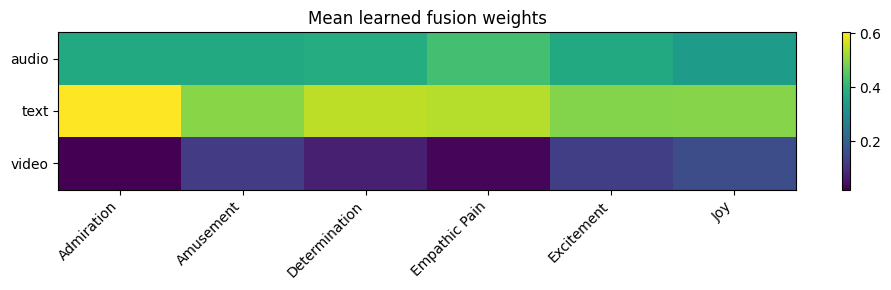

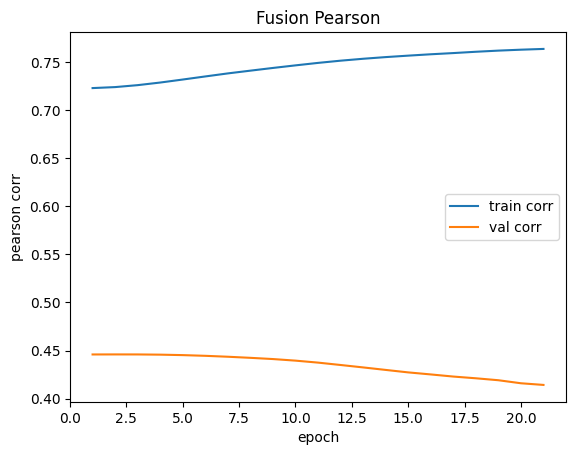

In [28]:
import matplotlib.pyplot as plt

def per_emotion_corr_np(P: np.ndarray, Y: np.ndarray, eps: float = 1e-8):
    out = {}
    for i, name in enumerate(EMOTIONS):
        x = P[:, i].astype(np.float64)
        y = Y[:, i].astype(np.float64)
        vx = x - x.mean(); vy = y - y.mean()
        out[name] = float((vx*vy).sum() / (np.sqrt((vx*vx).sum() * (vy*vy).sum()) + eps))
    return out

# load best
ckpt = torch.load(FUSION_CKPT, map_location=DEVICE, weights_only=False)
fusion.load_state_dict(ckpt["model_state"])
fusion.eval()
print("Loaded best fusion epoch:", ckpt["epoch"], "best_corr:", ckpt["best_corr"])

# collect preds on val
@torch.inference_mode()
def collect_fusion_preds(model, loader):
    Ps, Ys, Ws = [], [], []
    for Pm, Am, y in loader:
        Pm = Pm.to(DEVICE); Am = Am.to(DEVICE); y = y.to(DEVICE)
        out, w = model(Pm, Am)
        Ps.append(out.detach().cpu().numpy())
        Ys.append(y.detach().cpu().numpy())
        Ws.append(w.detach().cpu().numpy())
    return np.concatenate(Ps,0), np.concatenate(Ys,0), np.concatenate(Ws,0)

P_va_f, Y_va_f, W_va = collect_fusion_preds(fusion, valid_loader)

mean_corr = float(np.mean(list(per_emotion_corr_np(P_va_f, Y_va_f).values())))
print("Val mean corr:", mean_corr)

per = per_emotion_corr_np(P_va_f, Y_va_f)
print("Per-emotion VAL corr (fusion):")
for e in EMOTIONS:
    print(f"{e:14s}: {per[e]:.4f}")

# show average learned weights per emotion
W_mean = W_va.mean(axis=0)  # [M,E]
print("\nMean fusion weights (modalities x emotions):")
for mi, mname in enumerate(MODS):
    print(mname, ":", {EMOTIONS[e]: float(W_mean[mi,e]) for e in range(E)})

# heatmap
plt.figure(figsize=(10,3))
plt.imshow(W_mean, aspect="auto")
plt.yticks(range(M), MODS)
plt.xticks(range(E), EMOTIONS, rotation=45, ha="right")
plt.colorbar()
plt.title("Mean learned fusion weights")
plt.tight_layout()
plt.show()

# curves
epochs = np.arange(1, len(history["train_loss"])+1)
plt.figure()
plt.plot(epochs, history["train_corr"], label="train corr")
plt.plot(epochs, history["val_corr"], label="val corr")
plt.xlabel("epoch"); plt.ylabel("pearson corr"); plt.legend(); plt.title("Fusion Pearson"); plt.show()